# Segmentação de Imagens com ClipSeg

Este notebook utiliza o modelo **CIDAS/clipseg-rd64-refined** para realizar segmentação semântica baseada em texto. O ClipSeg é extremamente versátil pois permite segmentar qualquer objeto apenas descrevendo-o com palavras.

### Tecnologias Utilizadas:
- **Hugging Face Transformers**: Para carregar o modelo pré-treinado.
- **PyTorch**: Backend de processamento tensorial.
- **Pillow (PIL)**: Para manipulação de imagens.
- **Matplotlib**: Para visualização dos resultados.

In [ ]:
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation
from PIL import Image
import torch
import matplotlib.pyplot as plt
import os
import numpy as np

## 1. Configuração do Modelo

Carregamos o modelo e o processador diretamente do Hugging Face Hub.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

processor = CLIPSegProcessor.from_pretrained("CIDAS/clipseg-rd64-refined")
model = CLIPSegForImageSegmentation.from_pretrained("CIDAS/clipseg-rd64-refined").to(device)

## 2. Carregamento das Imagens

Listamos as imagens disponíveis na pasta `imagens`.

In [ ]:
image_folder = "imagens"
if not os.path.exists(image_folder):
    print(f"Erro: Pasta '{image_folder}' não encontrada.")
    images = []
else:
    images = [f for f in os.listdir(image_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"Imagens encontradas: {images}")

## 3. Função de Segmentação

Esta função recebe o caminho de uma imagem e uma lista de prompts de texto, retornando as máscaras de segmentação.

In [ ]:
def segment_image(image_path, prompts):
    image = Image.open(image_path).convert("RGB")
    
    # O ClipSeg processa texto e imagem simultaneamente
    inputs = processor(text=prompts, images=[image] * len(prompts), padding="max_length", return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    preds = outputs.logits
    if len(prompts) == 1:
        preds = preds.unsqueeze(0)
    
    # Visualização
    n_prompts = len(prompts)
    fig, ax = plt.subplots(1, n_prompts + 1, figsize=(4 * (n_prompts + 1), 4))
    
    ax[0].imshow(image)
    ax[0].set_title("Original")
    ax[0].axis("off")
    
    for i, prompt in enumerate(prompts):
        # Aplicar sigmoid para obter valores entre 0 e 1
        mask = torch.sigmoid(preds[i]).cpu().numpy()
        
        ax[i+1].imshow(mask, cmap="viridis")
        ax[i+1].set_title(f"Mask: '{prompt}'")
        ax[i+1].axis("off")
    
    plt.suptitle(f"Arquivo: {os.path.basename(image_path)}", fontsize=16)
    plt.tight_layout()
    plt.show()

## 4. Execução em Lote

Processamos todas as imagens com prompts sugeridos.

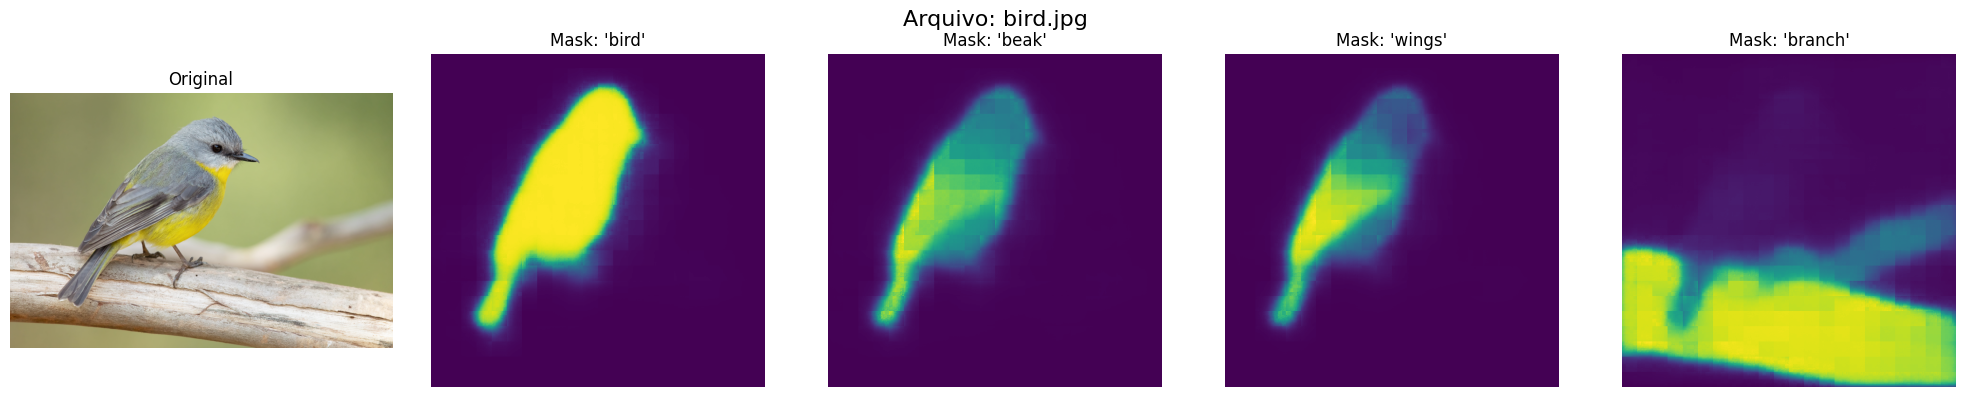

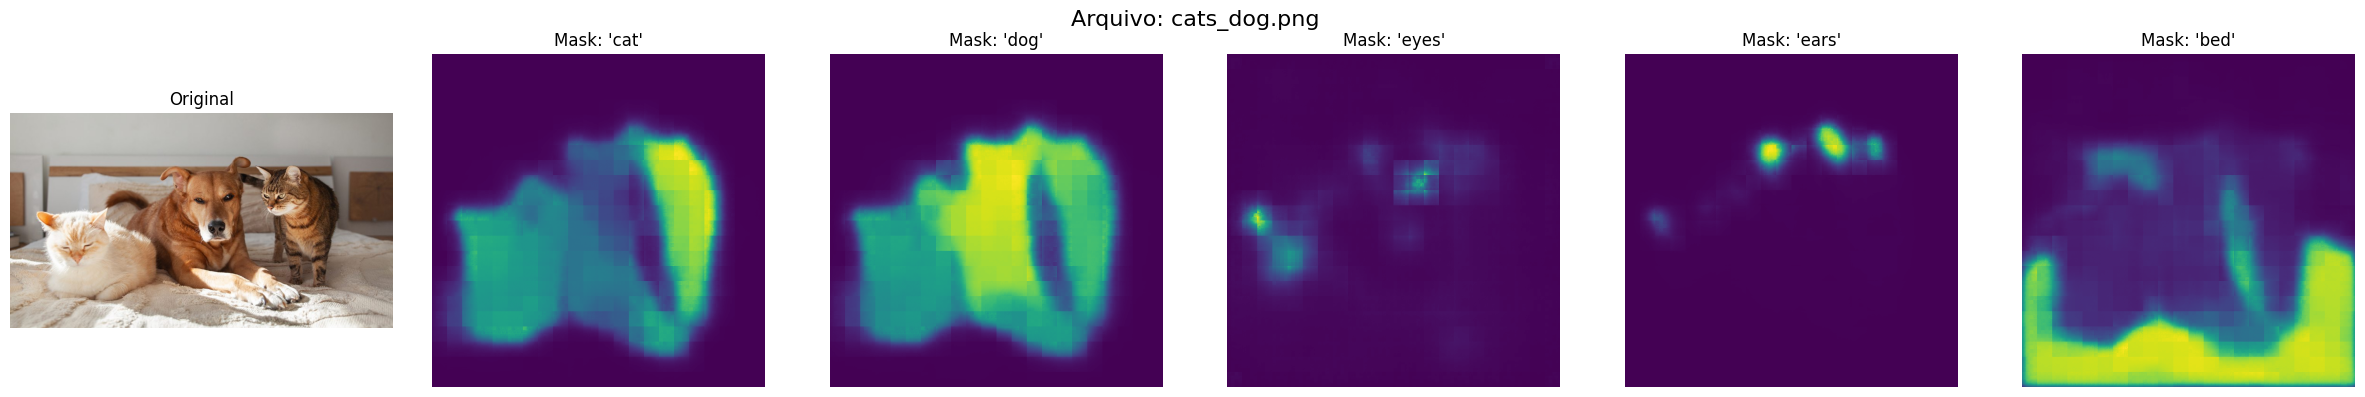

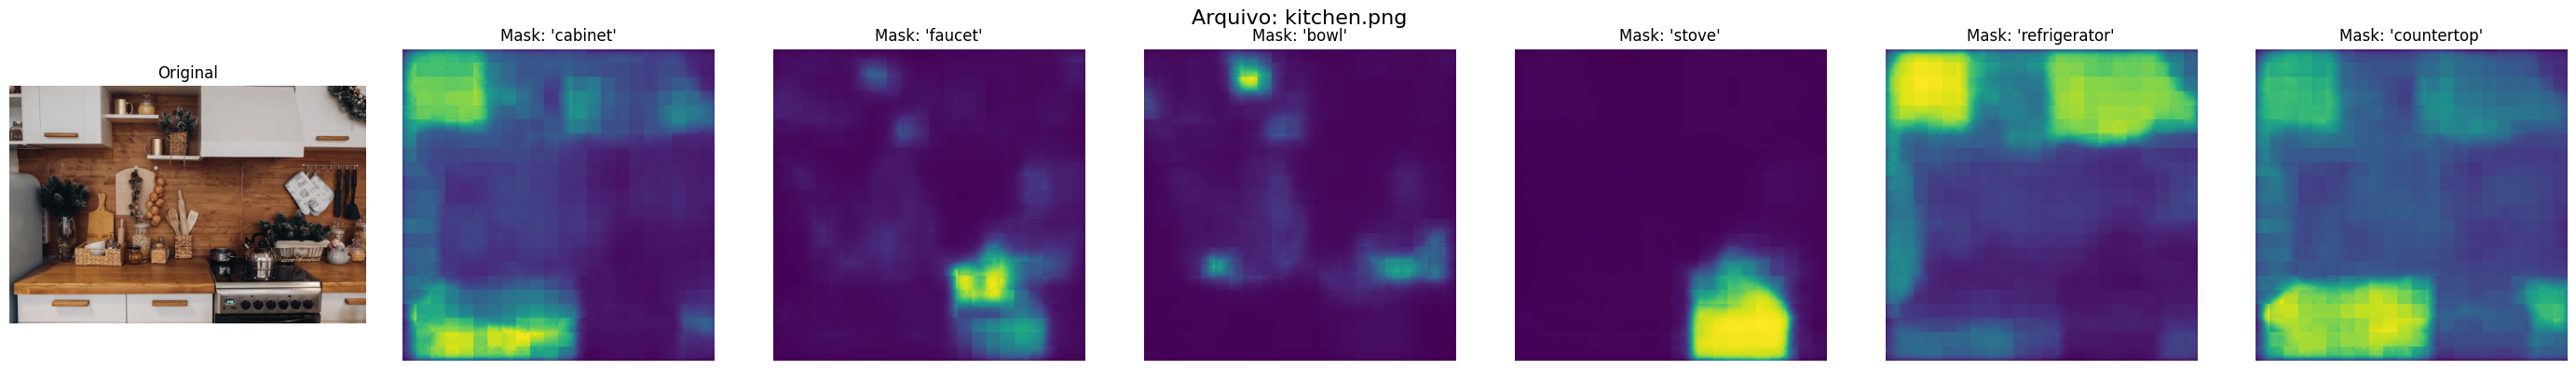

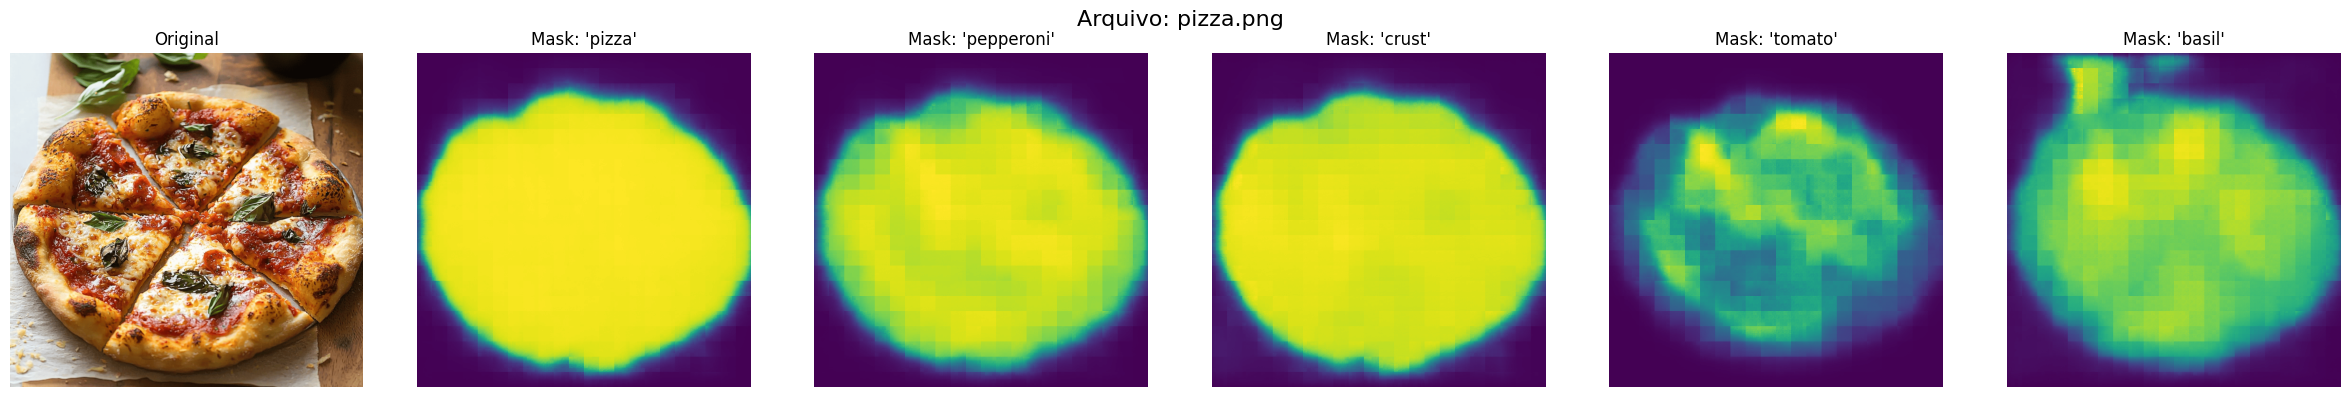

In [12]:
for img_name in images:
    img_path = os.path.join(image_folder, img_name)
    
    # Lógica simples para escolher prompts baseados no nome do arquivo
    lower_name = img_name.lower()
    if "cat" in lower_name or "dog" in lower_name:
        prompts = ["cat", "dog", "eyes", "ears","bed"]
    elif "bird" in lower_name:
        prompts = ["bird", "beak", "wings","branch"]
    elif "pizza" in lower_name:
        prompts = ["pizza", "pepperoni", "crust","tomato","basil"]
    elif "kitchen" in lower_name:
        prompts = ["cabinet", "faucet", "bowl", "stove","refrigerator","countertop"]    
    elif "bed" in lower_name:
        prompts = ["bed", "pillow", "sheet", "bedding"]
    else:
        prompts = ["main object", "background"]
    
    segment_image(img_path, prompts)